===== SIMPLE LINEAR REGRESSION =====
Coefficient: 1.92
Intercept: 1.29
MSE: 2.61
R2 Score: 0.93
6 hours -> Predicted Score: 12.80
7 hours -> Predicted Score: 14.72
8 hours -> Predicted Score: 16.64


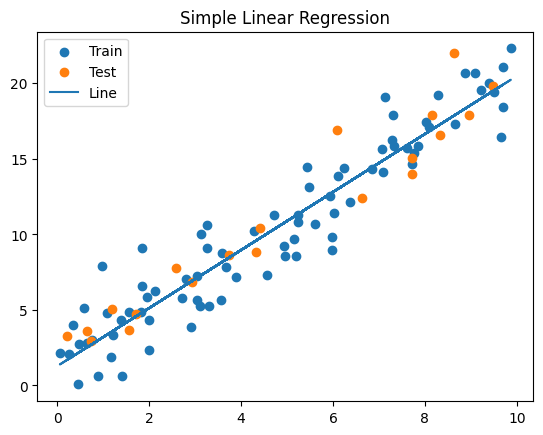


===== MULTIPLE LINEAR REGRESSION =====
Coefficients: [ 5.75 -1.5  -1.5 ]
Intercept: 59.250000000000014
MSE: 3.91
R2 Score: 0.98

Predicted Score (6 hrs, 3 tests, 7 sleep): 78.75


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


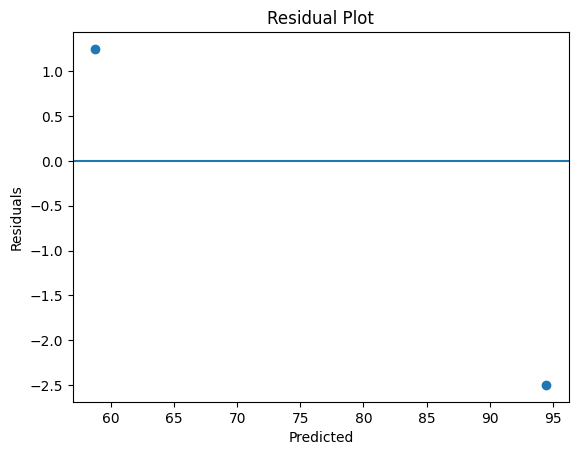

In [ ]:
# ============================================
# 📘 Linear Regression Complete Implementation
# ============================================

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ============================================
# 🔹 PART 1: SIMPLE LINEAR REGRESSION
# ============================================

# Generate Data (Hours studied vs Score)
np.random.seed(42)
X = np.random.rand(100, 1) * 10
y = 2 * X + 1 + np.random.randn(100, 1) * 2

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("===== SIMPLE LINEAR REGRESSION =====")
print(f"Coefficient: {model.coef_[0][0]:.2f}")
print(f"Intercept: {model.intercept_[0]:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

# New Predictions
X_new = np.array([[6], [7], [8]])
y_new = model.predict(X_new)

for h, s in zip(X_new, y_new):
    print(f"{h[0]} hours -> Predicted Score: {s[0]:.2f}")

# Plot
plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label="Test")
plt.plot(X, model.predict(X), label="Line")
plt.legend()
plt.title("Simple Linear Regression")
plt.show()


# ============================================
# 🔹 PART 2: MULTIPLE LINEAR REGRESSION
# ============================================

# Create Dataset
data = {
    'Hours': [1,2,3,4,5,6,7,8,9,10],
    'Practice': [1,2,2,3,3,4,4,5,5,6],
    'Sleep': [7,6,7,5,6,7,6,5,6,7],
    'Score': [50,60,65,70,75,80,85,90,92,95]
}

df = pd.DataFrame(data)

# Features & Target
X = df[['Hours', 'Practice', 'Sleep']]
y = df['Score']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== MULTIPLE LINEAR REGRESSION =====")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

# New Prediction
X_new = np.array([[6, 3, 7]])
y_new = model.predict(X_new)

print(f"\nPredicted Score (6 hrs, 3 tests, 7 sleep): {y_new[0]:.2f}")


# ============================================
# 🔹 BONUS: RESIDUAL ANALYSIS
# ============================================

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()